In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

I0000 00:00:1776536839.675341    3941 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU disponible: {gpus[0].name}")

GPU disponible: /physical_device:GPU:0


## CMAPSSData Preprocessing

In [3]:
#Eliminar sensores constantes
def eliminar_constantes(df, umbral_std=0.01):
    sensor_cols = [c for c in df.columns if c.startswith("s")]
    std = df[sensor_cols].std()
    constantes = std[std < umbral_std].index.tolist()
    print(f"Sensores eliminados por baja varianza: {constantes}")
    return df.drop(columns=constantes), constantes

#Calcular y añadir la etiqueta RUL
def add_rul_train(df, rul_max=110):
    """
    RUL real = ciclos restantes hasta el fallo.
    Se trunca a rul_max (cap lineal): permite que el modelo se centre en los ciclos 
    cercanos al fallo. No hay necesidad de predecir el fallo desde el inicio del trayecto.
    """
    max_ciclo = df.groupby("motor_id")["ciclo"].max().rename("ciclo_max")
    df = df.join(max_ciclo, on="motor_id")
    df["rul"] = (df["ciclo_max"] - df["ciclo"]).clip(upper=rul_max)
    df = df.drop(columns=["ciclo_max"])
    return df

def add_rul_test(df, rul_finales, rul_max=110):
    """
    En test, NASA proporciona cuántos ciclos quedaban al final
    del fragmento observado. Se suman los ciclos restantes y se calcula
    el RUL para cada ciclo de cada motor
    """
    rul_map = {
        motor_id + 1: rul
        for motor_id, rul in enumerate(rul_finales["rul_final"].values)
    }
    max_ciclo = df.groupby("motor_id")["ciclo"].max()
    
    def rul_para_motor(row):
        rul_final = rul_map[row["motor_id"]]
        ciclos_restantes = (max_ciclo[row["motor_id"]] - row["ciclo"]) + rul_final
        return min(ciclos_restantes, rul_max)
    
    df["rul"] = df.apply(rul_para_motor, axis=1)
    return df

def norm(train_df, test_df, feature_cols):
    """
    MinMaxScaler ajustado SOLO sobre train.
    Aplica la misma transformación a test sin re-ajustar.
    """
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols] = scaler.transform(test_df[feature_cols]) 
    
    return train_df, test_df, scaler

def crear_ventanas(df, feature_cols, window_size=30):
    """
    Para cada motor, recorre sus ciclos con una ventana de tamaño window_size.
    Si el motor tiene menos ciclos que window_size, se rellena con padding
    al principio (ceros)
    
    Devuelve:
        X: (N, window_size, n_features)
        y: (N,)  — RUL en el último ciclo de cada ventana
    """
    X_list, y_list = [], []
    
    for motor_id, motor in df.groupby("motor_id"):
        datos = motor[feature_cols].values   # (ciclos, n_features)
        etiqueta = motor["rul"].values           # (ciclos,)
        n_ciclos = len(datos)
        
        if n_ciclos < window_size:
            # Padding al principio con ceros
            pad = np.zeros((window_size - n_ciclos, datos.shape[1]))
            datos = np.vstack([pad, datos])
            etiqueta = np.concatenate([np.full(window_size - n_ciclos, etiqueta[0]), etiqueta])
            n_ciclos = window_size
        
        for i in range(n_ciclos - window_size + 1):
            X_list.append(datos[i : i + window_size])
            y_list.append(etiqueta[i + window_size - 1])   # RUL del último ciclo
    
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def crear_ventanas_test(df, feature_cols, window_size=30):
    """
    Se usa la última ventana de cada motor
    """
    X_list, y_list = [], []
    
    for motor_id, motor in df.groupby("motor_id"):
        datos = motor[feature_cols].values
        etiqueta = motor["rul"].values
        n_ciclos = len(datos)
        
        if n_ciclos >= window_size:
            X_list.append(datos[-window_size:])
        else:
            pad = np.zeros((window_size - n_ciclos, datos.shape[1]))
            ventana = np.vstack([pad, datos])
            X_list.append(ventana)
        
        y_list.append(etiqueta[-1])
    
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


In [4]:
from scipy import stats
#Crear una desviación para cada sensor respecto del inicio de los ciclos
def add_degradation_features(df,feature_cols,window_slope=10, suavizado=3):
    """
    Añadir un índice de cambio respecto al inicio de la medición.
    Cuando el cambio es grande => mayor degradación.
    Añadir un slope respecto de la anterior ventana (sub-ventana de entrenamiento)
    Añadir una aceleración de degradación, indicar si los valores están cambiando rápido o despacio.
    Ignorar op_n ya que no indican degradación, indican el régimen de vuelo que se está llevando a cabo.
    """
    df = df.copy()
    for motor_id, motor in df.groupby("motor_id"):
        idx = motor.index
        for sensor in feature_cols:
            # add variación de valor entre el primer ciclo y el n-ciclo
            value = motor[sensor].values
            delta = value - value[0]
            df.loc[idx,f"{sensor}_delta"] = delta 

            # add slope respecto a la anterior ventana
            slope = np.zeros(len(value))
            for t in range(len(value)):
                inicio = max(0, t - window_slope + 1)
                ventana = value[inicio : t + 1]
                if len(ventana) >= 3:   
                    x = np.arange(len(ventana))
                    slope[t] = stats.linregress(x, ventana).slope # la pendiente de la recta que mejor ajusta los valores del sensor en una ventana
                else:
                    slope[t] = 0.0
            df.loc[idx, f"{sensor}_slope"] = slope

            # add aceleración, se suaviza el slope para reducir ruido
            slope_suav = pd.Series(slope).rolling(
                window=suavizado, min_periods=1
            ).mean().values
            accel = np.gradient(slope_suav)  
            df.loc[idx, f"{sensor}_accel"] = accel

    return df

In [5]:
def preparar_dataset(window_size=60, rul_max=110):

    COLS = (
    ["motor_id", "ciclo"] +
    [f"op_{i}" for i in range(1, 4)] +          # 3 configuraciones operacionales
    [f"s{i}" for i in range(1, 22)]             # 21 sensores
    )
    
    train_data = pd.read_csv('../CMAPSSData/train_FD001.txt', sep=r"\s+", header=None, names=COLS)
    test_data = pd.read_csv('../CMAPSSData/test_FD001.txt',  sep=r"\s+", header=None, names=COLS)
    rul = pd.read_csv('../CMAPSSData/RUL_FD001.txt',   sep=r"\s+", header=None, names=["rul_final"])
    
    # Añadir etiquetas RUL
    train_df = add_rul_train(train_data.copy(), rul_max=rul_max)
    test_df  = add_rul_test(test_data.copy(), rul, rul_max=rul_max)

    # Eliminar sensores constantes (calculado sobre train)
    sensor_cols = [c for c in train_df.columns if c.startswith("s")]
    std = train_df[sensor_cols].std()
    constantes = std[std < 0.01].index.tolist()
    train_df = train_df.drop(columns=constantes)
    test_df  = test_df.drop(columns=constantes)

    # Columnas para calcular degradación 
    deg_cols = [c for c in train_df.columns if c.startswith("s")]

    # Añadir columnas de degradación
    print("Calculando features de degradación...")
    train_df = add_degradation_features(train_df, deg_cols)
    test_df  = add_degradation_features(test_df,  deg_cols)

    # Columnas que entran al modelo
    feature_cols = [c for c in train_df.columns if c.startswith("s") or c.startswith("op")]
    
    # Normalizar
    train_df, test_df, scaler = norm(train_df, test_df, feature_cols)

    # Ventanas
    X_train_full, y_train_full = crear_ventanas(train_df, feature_cols, window_size)
    X_test,  y_test  = crear_ventanas_test(test_df, feature_cols, window_size)

    # Split validación desde train
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.15, random_state=42
    )

    print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
    print(f"Features usadas: {len(feature_cols)}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), scaler, feature_cols


In [90]:
# Ejemplo de uso:
(X_tr, y_tr), (X_val, y_val), (X_te, y_te), scaler, feats = preparar_dataset()
# model.fit(X_tr, y_tr, validation_data=(X_val, y_val), ...)

Calculando features de degradación...
X_train: (15071, 30, 59)  y_train: (15071,)
X_val:   (2660, 30, 59)    y_val:   (2660,)
X_test:  (100, 30, 59)   y_test:  (100,)
Features usadas: 59


## 1D_CNN

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

In [7]:
#Construcción CNN reutilizable
def bloque_conv(x, filtros, kernel_size, dilation_rate=1, nombre=""):
    """
    Unidad básica: Conv1D → BatchNorm → ReLU → Dropout ligero.
    dilation_rate > 1 amplía el campo receptivo sin aumentar parámetros.
    """
    x = layers.Conv1D(
        filters      = filtros,
        kernel_size  = kernel_size,
        padding      = "same",          # conserva la longitud temporal
        dilation_rate= dilation_rate,
        use_bias     = False,           # BatchNorm tiene su propio bias
        name         = f"conv_{nombre}"
    )(x)
    x = layers.BatchNormalization(name=f"bn_{nombre}")(x)
    x = layers.Activation("relu", name=f"relu_{nombre}")(x)
    return x


def build_cnn_block(inp, filtros=64, nombre_base="cnn"):
    """
    Tres capas convolucionales con kernel sizes distintos (3, 5, 3)
    y la tercera con dilation=2 para capturar tendencias más largas.

    Entrada:  (batch, window_size, n_sensores)
    Salida:   (batch, window_size, filtros)  ← misma longitud temporal
    """
    # Capa 1 — patrones locales finos (3 ciclos)
    x = bloque_conv(inp, filtros, kernel_size=3, nombre=f"{nombre_base}_1")

    # Capa 2 — patrones medios (5 ciclos)
    x = bloque_conv(x,   filtros, kernel_size=5, nombre=f"{nombre_base}_2")

    # Capa 3 — patrones dilatados: campo receptivo = 5 ciclos con solo 3 pesos
    x = bloque_conv(x,   filtros, kernel_size=3,
                    dilation_rate=2, nombre=f"{nombre_base}_3")

    # Conexión residual: si el número de canales cambia, proyectar con Conv 1×1
    if inp.shape[-1] != filtros:
        shortcut = layers.Conv1D(filtros, 1, padding="same",
                                 use_bias=False, name=f"{nombre_base}_proj")(inp)
        shortcut = layers.BatchNormalization(name=f"{nombre_base}_bn_proj")(shortcut)
    else:
        shortcut = inp

    x = layers.Add(name=f"{nombre_base}_residual")([x, shortcut])
    x = layers.Activation("relu", name=f"{nombre_base}_out")(x)
    return x

In [8]:
def build_cnn_block(inp, filtros=64):
    """
    Versión sin residual — más fácil de leer, funciona bien para CMAPSS.
    La dimensión temporal se conserva gracias a padding='same'.
    NO hay Flatten porque la salida va al BiLSTM.
    """
    x = layers.Conv1D(filtros, kernel_size=3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(filtros, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(filtros, kernel_size=3, padding="same",
                      dilation_rate=2, activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Salida: (batch, window_size, filtros) — secuencia intacta para el BiLSTM
    return x

## Capa de Atención

In [9]:
#Capa de atención
class BahdanauAttention(layers.Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=True)
        self.v = layers.Dense(1, use_bias=False)

    def call(self, h):
        score = self.v(tf.nn.tanh(self.W(h))) # (batch, T, 1)
        weights = tf.nn.softmax(score, axis=1) # (batch, T, 1)
        context = tf.reduce_sum(weights * h, axis=1) # (batch, dim)
        return context, weights

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.W.units})
        return cfg

## Construcción del modelo

In [10]:
def build_model(window_size=80, n_features=19,
                cnn_filtros=64, lstm_units=64,
                attn_units=64, dropout=0.3):

    inp = Input(shape=(window_size, n_features), name="entrada")

    # 1. CNN — patrones espaciales entre sensores
    x = build_cnn_block(inp, filtros=cnn_filtros)
    # (batch, 30, 64)

    # 2. BiLSTM — dependencias temporales en ambas direcciones
    x = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True), name="bilstm_1")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True), name="bilstm_2")(x)
    x = layers.Dropout(dropout)(x)
    # (batch, 30, 128)  ← 128 porque Bidirectional concatena fwd + bwd

    # 3. Atención — pondera timesteps por relevancia
    context, attn_weights = BahdanauAttention(units=attn_units, name="atencion")(x)
    # context: (batch, 128)

    # 4. Top Model
    x = layers.Dense(128, activation="relu")(context)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    rul = layers.Dense(1, name="rul")(x)

    model = Model(inputs=inp, outputs=rul, name="CNN_BiLSTM_Attn")
    return model


#model = build_model()
#model.summary()

In [11]:
# ── Pérdida asimétrica NASA ─────────────────────────────────────────────────
# Penaliza más predecir que queda MÁS vida de la que realmente queda
# (un fallo no anticipado es mucho más peligroso que una revisión anticipada)

def nasa_score_loss(y_true, y_pred):
    diff = y_pred - y_true
    score = tf.where(
        diff < 0,
        tf.exp(-diff / 13.0) - 1,   # predicción pesimista — penaliza suave
        tf.exp( diff / 9.0) - 1    # predicción optimista — penaliza fuerte
    )
    return tf.reduce_mean(score)

def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

In [12]:
# ── Preparar datos (del pipeline de preprocesamiento anterior) ──────────────

(X_train, y_train), (X_val, y_val), (X_test, y_test), scaler, feats = preparar_dataset(window_size=60)

# ── Compilar ────────────────────────────────────────────────────────────────

model = build_model(
    window_size = 60, #Probando con una ventana mayor (antes 30)
    n_features = X_train.shape[2],   # se adapta automáticamente a los sensores útiles
    cnn_filtros = 64,
    lstm_units = 64,
    attn_units = 64,
    dropout = 0.3
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor = "val_loss",
        patience = 20,
        restore_best_weights = True,
        verbose = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = "val_loss",
        factor = 0.5,
        patience = 8,
        min_lr = 1e-6,
        verbose = 1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath = "best_model.keras",
        monitor = "val_rmse",     # guardamos el mejor RMSE, no el mejor loss
        mode = "min",
        save_best_only = True,
        verbose = 1
    ),
    tf.keras.callbacks.CSVLogger("historial_entrenamiento.csv")
]

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss = nasa_score_loss,
    metrics = [rmse, "mae","acc"]
)

Calculando features de degradación...


KeyboardInterrupt: 

In [ ]:
import time

def sample_weights(y_true, factor_medio=2.0, factor_critico=4.0):
    w = np.ones_like(y_true, dtype=np.float32)
    w[y_true < 80] = factor_medio      # zona donde están los motores 27, 79, 21...
    w[y_true < 30] = factor_critico    # zona crítica
    return w

pesos = sample_weights(y_train)

inicio = time.time()
historial = model.fit(
    X_train, y_train,
    #sample_weight = pesos,
    validation_data = (X_val, y_val),
    epochs          = 150,
    batch_size      = 256,
    callbacks       = callbacks,
    verbose         = 1
)
final = time.time()
print(f"Tiempo de entrenamiento con CPU: {final-inicio}s")

## Test

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step
RMSE  : 15.03 ciclos
MAE   : 11.16  ciclos
Score : 323.0   (menor es mejor, referencia paper ~338)


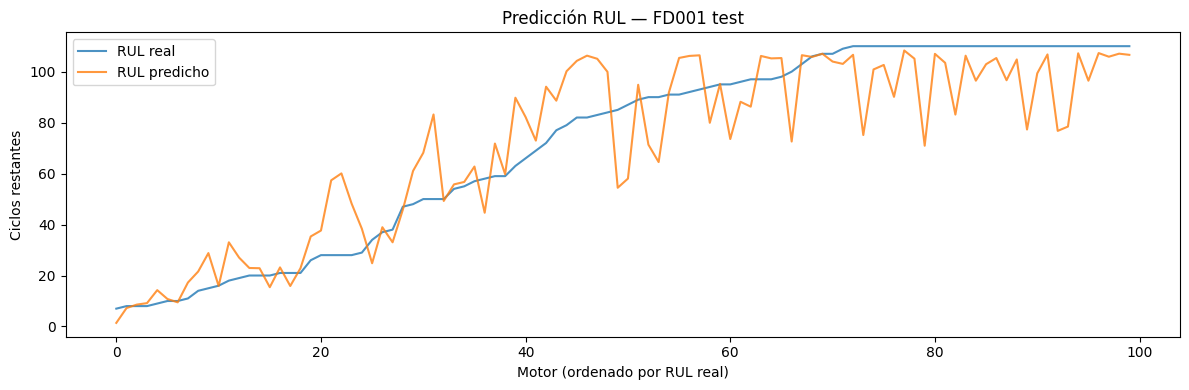

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step


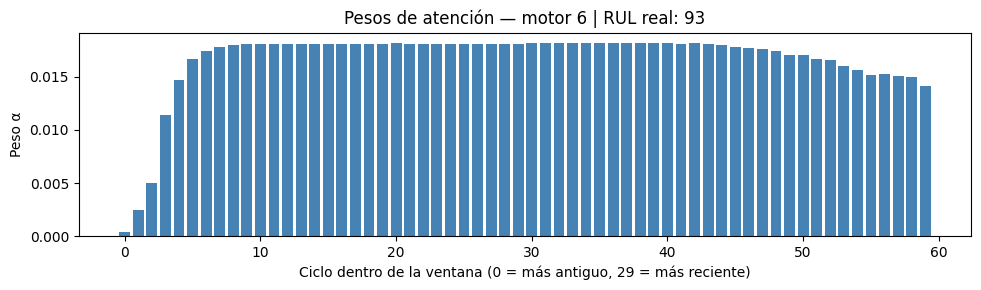

In [106]:
y_pred = model.predict(X_test).flatten()

rmse_val  = np.sqrt(np.mean((y_test - y_pred) ** 2))
mae_val   = np.mean(np.abs(y_test - y_pred))

def nasa_score_numpy(y_true, y_pred):
    diff = y_pred - y_true
    return np.sum(np.where(diff < 0,
                           np.exp(-diff / 13.0) - 1,
                           np.exp( diff / 10.0) - 1))

score_val = nasa_score_numpy(y_test, y_pred)

print(f"RMSE  : {rmse_val:.2f} ciclos")
print(f"MAE   : {mae_val:.2f}  ciclos")
print(f"Score : {score_val:.1f}   (menor es mejor, referencia paper ~338)")

# ── Visualizar predicciones vs real ─────────────────────────────────────────

import matplotlib.pyplot as plt

idx = np.argsort(y_test)   # ordenar por RUL real para ver la curva limpia
plt.figure(figsize=(12, 4))
plt.plot(y_test[idx],  label="RUL real",     alpha=0.8)
plt.plot(y_pred[idx],  label="RUL predicho", alpha=0.8)
plt.xlabel("Motor (ordenado por RUL real)")
plt.ylabel("Ciclos restantes")
plt.legend()
plt.title("Predicción RUL — FD001 test")
plt.tight_layout()
plt.show()

# ── Visualizar pesos de atención de un motor concreto ───────────────────────
# Construir modelo auxiliar que expone los pesos

model_attn = Model(
    inputs  = model.input,
    outputs = model.get_layer("atencion").output   # (context, weights)
)

motor_idx = 5   # cambia para explorar distintos motores
_, attn_w = model_attn.predict(X_test[motor_idx:motor_idx+1])
attn_w = attn_w[0, :, 0]   # (window_size,)

plt.figure(figsize=(10, 3))
plt.bar(range(len(attn_w)), attn_w, color="steelblue")
plt.xlabel("Ciclo dentro de la ventana (0 = más antiguo, 29 = más reciente)")
plt.ylabel("Peso α")
plt.title(f"Pesos de atención — motor {motor_idx+1} | RUL real: {y_test[motor_idx]:.0f}")
plt.tight_layout()
plt.show()

## Análisis de los fallos

In [107]:
y_pred = model.predict(X_test).flatten()
diff = y_pred - y_test

# Score por motor individual
score_por_motor = np.where(
    diff < 0,
    np.exp(-diff / 13.0) - 1,
    np.exp( diff / 10.0) - 1
)

# Ordenar de peor a mejor
idx_peores = np.argsort(score_por_motor)[::-1]

print("Los 10 motores con peor Score:")
print(f"{'Motor':>6}  {'RUL real':>9}  {'RUL pred':>9}  {'diff':>6}  {'score':>8}")
for i in idx_peores[:10]:
    print(f"{i+1:>6}  {y_test[i]:>9.1f}  {y_pred[i]:>9.1f}  "
          f"{diff[i]:>+6.1f}  {score_por_motor[i]:>8.2f}")

# Separar errores optimistas vs pesimistas
optimistas = diff > 0   # predicho > real → peligroso
pesimistas = diff < 0

print(f"\nErrores optimistas (pred > real): {optimistas.sum()} motores "
      f"— contribuyen {score_por_motor[optimistas].sum():.1f} al Score")
print(f"Errores pesimistas (pred < real): {pesimistas.sum()} motores "
      f"— contribuyen {score_por_motor[pesimistas].sum():.1f} al Score")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Los 10 motores con peor Score:
 Motor   RUL real   RUL pred    diff     score
    17       50.0       83.2   +33.2     26.65
    64       28.0       60.1   +32.1     23.72
    30      110.0       70.9   -39.1     19.18
    40       28.0       57.4   +29.4     17.83
    12      110.0       75.1   -34.9     13.62
    79       63.0       89.8   +26.8     13.54
    88      110.0       76.8   -33.2     11.90
    87      110.0       77.3   -32.7     11.36
    97       82.0      106.3   +24.3     10.33
    65      110.0       78.5   -31.5     10.32

Errores optimistas (pred > real): 49 motores — contribuyen 183.7 al Score
Errores pesimistas (pred < real): 51 motores — contribuyen 139.3 al Score


## Entrenamiento de 4 modelos para cada subset

In [108]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [121]:
def identificar_condicion_operacional(df, n_condiciones=6):
    """
    En FD002/FD004 hay 6 condiciones operacionales distintas.
    Las identificamos agrupando op_1, op_2, op_3 con KMeans.
    En FD001/FD003 con n_condiciones=1 asigna todo al cluster 0.
    """
    op_cols = ["op_1", "op_2", "op_3"]
    
    if n_condiciones == 1:
        df["condicion"] = 0
        return df
    
    km = KMeans(n_clusters=n_condiciones, random_state=42, n_init=10)
    df["condicion"] = km.fit_predict(df[op_cols])
    return df, km


def normalizar_por_condicion(train_df, test_df, feature_cols, n_condiciones):
    """
    Para FD002/FD004: ajusta un scaler distinto por condición operacional.
    Para FD001/FD003: normalización global (igual que antes).
    
    Esto evita que el modelo confunda variación por régimen de vuelo
    con variación por degradación.
    """
    train_df[feature_cols] = train_df[feature_cols].astype(np.float64)
    test_df[feature_cols]  = test_df[feature_cols].astype(np.float64)
    
    if n_condiciones == 1:
        scaler = MinMaxScaler()
        train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
        test_df[feature_cols]  = scaler.transform(test_df[feature_cols])
        return train_df, test_df, {0: scaler}
    
    scalers = {}
    for cond in range(n_condiciones):
        mask_train = train_df["condicion"] == cond
        mask_test = test_df["condicion"]  == cond
        
        if mask_train.sum() == 0:
            continue
            
        scaler = MinMaxScaler()
        train_df.loc[mask_train, feature_cols] = scaler.fit_transform(
            train_df.loc[mask_train, feature_cols]
        )
        if mask_test.sum() > 0:
            test_df.loc[mask_test, feature_cols] = scaler.transform(
                test_df.loc[mask_test, feature_cols]
            )
        scalers[cond] = scaler
    
    return train_df, test_df, scalers

In [119]:
CONFIG_DATASETS = {
    "FD001": {"n_condiciones": 1, "n_fallos": 1},
    "FD002": {"n_condiciones": 6, "n_fallos": 1},
    "FD003": {"n_condiciones": 1, "n_fallos": 2},
    "FD004": {"n_condiciones": 6, "n_fallos": 2},
}

def preparar_dataset_v3(ruta_base,subset,window_size=60, rul_max=110):

    config = CONFIG_DATASETS[subset]
    n_condiciones = config["n_condiciones"]

    COLS = (
    ["motor_id", "ciclo"] +
    [f"op_{i}" for i in range(1, 4)] +          # 3 configuraciones operacionales
    [f"s{i}" for i in range(1, 22)]             # 21 sensores
    )

    train = pd.read_csv(f"{ruta_base}/train_{subset}.txt", sep=r"\s+", header=None, names=COLS)
    test = pd.read_csv(f"{ruta_base}/test_{subset}.txt", sep=r"\s+", header=None, names=COLS)
    rul = pd.read_csv(f"{ruta_base}/RUL_{subset}.txt", sep=r"\s+", header=None, names=["rul_final"])
    
    train_df = add_rul_train(train.copy(), rul_max=rul_max)
    test_df = add_rul_test(test.copy(), rul, rul_max=rul_max)

    # Eliminar sensores constantes sobre train
    sensor_cols = [c for c in train_df.columns if c.startswith("s")]
    std = train_df[sensor_cols].std()
    constantes = std[std < 0.01].index.tolist()
    train_df = train_df.drop(columns=constantes)
    test_df = test_df.drop(columns=constantes)
    sensor_cols = [c for c in sensor_cols if c not in constantes]

    # Identificar condición operacional
    if n_condiciones > 1:
        train_df, km = identificar_condicion_operacional(train_df, n_condiciones)
        # Aplicar el mismo KMeans al test — no re-ajustar
        test_df["condicion"] = km.predict(test_df[["op_1","op_2","op_3"]])
    else:
        train_df = identificar_condicion_operacional(train_df, 1)
        test_df["condicion"] = 0

    # Columnas para calcular degradación 
    deg_cols = [c for c in train_df.columns if c.startswith("s")]
    
    # Features de degradación
    print(f"[{subset}] Calculando features de degradación...")
    train_df = add_degradation_features(train_df, deg_cols)
    test_df = add_degradation_features(test_df,  deg_cols)

    # Columnas que entran al modelo
    feature_cols = [c for c in train_df.columns if c.startswith("s") or c.startswith("op")]

    # Normalizar — por condición si FD002/FD004
    train_df, test_df, scalers = normalizar_por_condicion(train_df, test_df, feature_cols, n_condiciones)

    # Ventanas
    X_tr_full, y_tr_full = crear_ventanas(train_df, feature_cols, window_size)
    X_test, y_test = crear_ventanas_test(test_df, feature_cols, window_size)

    X_train, X_val, y_train, y_val = train_test_split(X_tr_full, y_tr_full, test_size=0.15, random_state=42)

    print(f"[{subset}] Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
    print(f"[{subset}] Features: {len(feature_cols)} | Condiciones: {n_condiciones}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), scalers, feature_cols


def entrenar_dataset(subset, ruta_base="../CMAPSSData", window_size=60):

    (X_tr, y_tr), (X_val, y_val), (X_test, y_test), scalers, feats = preparar_dataset_v3(ruta_base, subset, window_size)

    # FD002/FD004 tienen más variabilidad — más capacidad en BiLSTM
    lstm_units = 64 if CONFIG_DATASETS[subset]["n_condiciones"] == 1 else 128

    model = build_model(
        window_size = window_size,
        n_features  = X_tr.shape[2],
        cnn_filtros = 64,
        lstm_units  = lstm_units,
        attn_units  = 64,
        dropout     = 0.3
    )

    model.compile(
        optimizer = tf.keras.optimizers.Adam(1e-3),
        loss      = nasa_score_loss,
        metrics   = [rmse, "mae", "acc"]
    )

    #pesos = sample_weights(y_tr)

    callbacks_subset = [
        tf.keras.callbacks.EarlyStopping(
            patience=20, restore_best_weights=True, monitor="val_loss"
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.5, patience=8, min_lr=1e-6, monitor="val_loss"
        ),
        tf.keras.callbacks.ModelCheckpoint(
            f"modelo_{subset}.keras", save_best_only=True, monitor="val_rmse", mode="min"
        ),
    ]

    historial = model.fit(
        X_tr, y_tr,
        #sample_weight   = pesos,
        validation_data = (X_val, y_val),
        epochs          = 150,
        batch_size      = 256,
        callbacks       = callbacks_subset,
        verbose         = 1
    )

    return model, historial, (X_test, y_test)


def evaluar(model, X_test, y_test, subset):

    y_pred = model.predict(X_test).flatten()
    diff   = y_pred - y_test

    score_por_motor = np.where(
        diff < 0,
        np.exp(-diff / 13.0) - 1,
        np.exp( diff / 10.0) - 1
    )

    rmse_v  = np.sqrt(np.mean((y_test - y_pred)**2))
    mae_v   = np.mean(np.abs(y_test - y_pred))
    score_v = score_por_motor.sum()

    print(f"\n── {subset} ─────────────────────────")
    print(f"RMSE  : {rmse_v:.2f}")
    print(f"MAE   : {mae_v:.2f}")
    print(f"Score : {score_v:.1f}")

    return {"subset": subset, "rmse": rmse_v, "mae": mae_v, "score": score_v}

In [ ]:
resultados = []

for subset in ["FD001", "FD002", "FD003", "FD004"]:
    print(f"\n{'='*50}")
    print(f"Entrenando {subset}...")
    model, hist, (X_te, y_te) = entrenar_dataset(subset)
    res = evaluar(model, X_te, y_te, subset)
    resultados.append(res)

# Tabla resumen
print("\n── Resumen final ──────────────────────────────")
print(f"{'Dataset':>8}  {'RMSE':>6}  {'MAE':>6}  {'Score':>8}  {'Ref. paper':>10}")
refs = {"FD001": 338, "FD002": 3551, "FD003": 652, "FD004": 5765}
for r in resultados:
    print(f"{r['subset']:>8}  {r['rmse']:>6.2f}  {r['mae']:>6.2f}  "
          f"{r['score']:>8.1f}  {refs[r['subset']]:>10}")